Cluster Counts:
cluster
0     309
1    3468
2    2190
3     959
Name: count, dtype: int64


,name,year,selling_price,km_driven,fuel,transmission,cluster
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Manual,1
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Manual,1
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Manual,2
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Manual,2
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Manual,2
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Manual,1
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Manual,2
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Manual,2
8,Toyota Etios VXD,2011,350000,90000,Diesel,Manual,2
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Manual,2


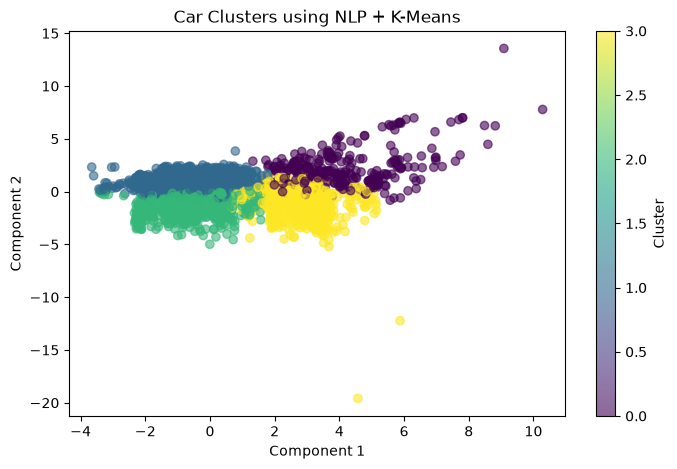

Done! File saved as Car_details_v3_clustered.csv


In [1]:
# CAR DETAILS V3 - NLP + K-MEANS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# 1. Load dataset
df = pd.read_csv("Car details v3.csv")

# 2. Clean column names
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
df = df.drop_duplicates()

# 3. Convert numerical columns
num_cols = ['year','selling_price','km_driven','mileage',
            'engine','max_power','seats']

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.extract(r'(\d+\.?\d*)')[0],
            errors='coerce'
        )
        df[col] = df[col].fillna(df[col].median())

# 4. NLP - use car name
text_col = 'name'
df[text_col] = df[text_col].fillna("unknown")

tfidf = TfidfVectorizer(stop_words='english', max_features=500)
text = tfidf.fit_transform(df[text_col])

# 5. Scale numerical data
features = [c for c in num_cols if c in df.columns]

scaler = StandardScaler()
X_num = scaler.fit_transform(df[features])

# 6. Combine NLP + numerical data
from scipy.sparse import hstack, csr_matrix

X = hstack([csr_matrix(X_num), text])

# 7. K-Means
k = 4

model = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df['cluster'] = model.fit_predict(X)

# 8. Cluster results
print("Cluster Counts:")
print(df['cluster'].value_counts().sort_index())

# 9. Show results
cols = [c for c in [
    'name','year','selling_price','km_driven',
    'fuel','transmission','cluster'
] if c in df.columns]

display(df[cols].head(20))

# 10. Visualise clusters
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)

plt.figure(figsize=(8,5))
plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=df['cluster'],
    alpha=0.6
)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Car Clusters using NLP + K-Means")
plt.colorbar(label="Cluster")
plt.show()

# 11. Save results
df.to_csv("Car_details_v3_clustered.csv", index=False)

print("Done! File saved as Car_details_v3_clustered.csv")